In [1]:
import sys
import os
import pandas as pd

current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
if parent_dir not in sys.path:
    sys.path.append(parent_dir)
%load_ext autoreload
%autoreload 2

In [2]:
from hep_rewgt_tk.reweight_app import SingleXGBReweighter
from hep_rewgt_tk.reweight_nn import GANReweighter

## Pre-clean datasets

In [3]:
ABCD_dir = "/Users/yuntongzhou/Desktop/Dihiggszztt/output/ABCD"

In [4]:
Res1b_SS = pd.read_csv(f'{ABCD_dir}/Res1b_SS.csv', index_col=0)
Res1b_OS = pd.read_csv(f'{ABCD_dir}/Res1b_OS.csv', index_col=0)
Res2b_SS = pd.read_csv(f'{ABCD_dir}/Res2b_SS.csv', index_col=0)
Res2b_OS = pd.read_csv(f'{ABCD_dir}/Res2b_OS.csv', index_col=0)

In [5]:
def apply_all(dfs, func):
    filtered = [None] * len(dfs)
    for i, df in enumerate(dfs):
        filtered[i] = func(df.copy())
    return filtered

In [6]:
def keep_fake_ttbar(df):
    df = df[df.group=='TTbar']
    cond_1 = df['LDTau_genflav'] < 5
    cond_2 = df['SDTau_genflav'] < 5 
    return df[((cond_1) | (cond_2))]

def keep_real_ttbar(df):
    df = df[df.group=='TTbar']
    cond_1 = df['LDTau_genflav'] >= 5
    cond_2 = df['SDTau_genflav'] >= 5 
    return df[((cond_1) | (cond_2))]

In [57]:
def signal_id_level(df):
    mask_1 = df['LDTau_idvsjet'] >= 1 # VVV loose WP
    mask_2 = df['SDTau_idvsjet'] >= 1 # VVV loose WP
    mask_3 = df['LDTau_idvse'] >= 3 # VLoose
    mask_4 = df['SDTau_idvse'] >= 3 # VLoose
    mask_5 = df['LDTau_idvsmu'] >= 4 # Tight
    mask_6 = df['SDTau_idvsmu'] >= 4 # Tight
    return df[(mask_1) & (mask_2) & (mask_3) & (mask_4) & (mask_5) & (mask_6)]

In [76]:
df_2b = signal_id_level(pd.concat([Res2b_SS, Res2b_OS], ignore_index=True, axis=0))
df_1b = signal_id_level(pd.concat([Res1b_SS, Res1b_OS], ignore_index=True, axis=0))

In [77]:
from src.utils.mathutil import ABCDUtil
from src.utils.plotutil import PlotUtil
ABCDUtil.pearson_corr(df_1b, 'OS', 'DiJet_mass')

Pearson Correlation Coefficient: -0.00027103120713087487
P-value: 0.8813860798869911


In [78]:
plot_dir = "/Users/yuntongzhou/Desktop/Dihiggszztt/output/plots/ABCD_ttOnly"

### Resolved 1b

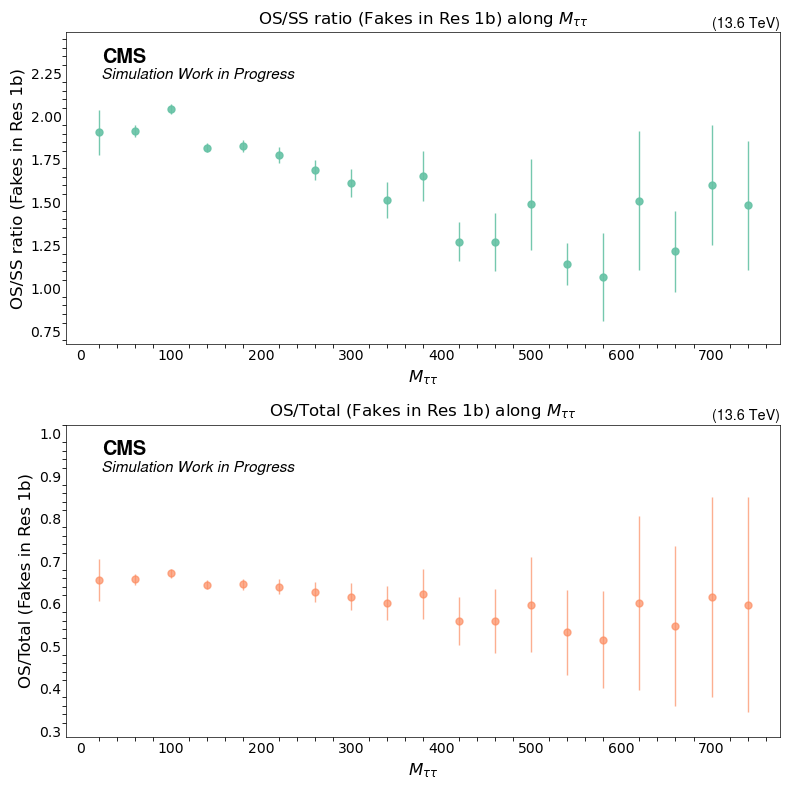

In [79]:
PlotUtil.corr_discrete(df_1b, 'OS', 'DiTau_mass', r'$M_{\tau \tau}$', 'OS/SS ratio (Fakes in Res 1b)', 'OS/Total (Fakes in Res 1b)', f'{plot_dir}/OSRatio_DiTauM_1b.png', 20, (0, 800), 'weight')

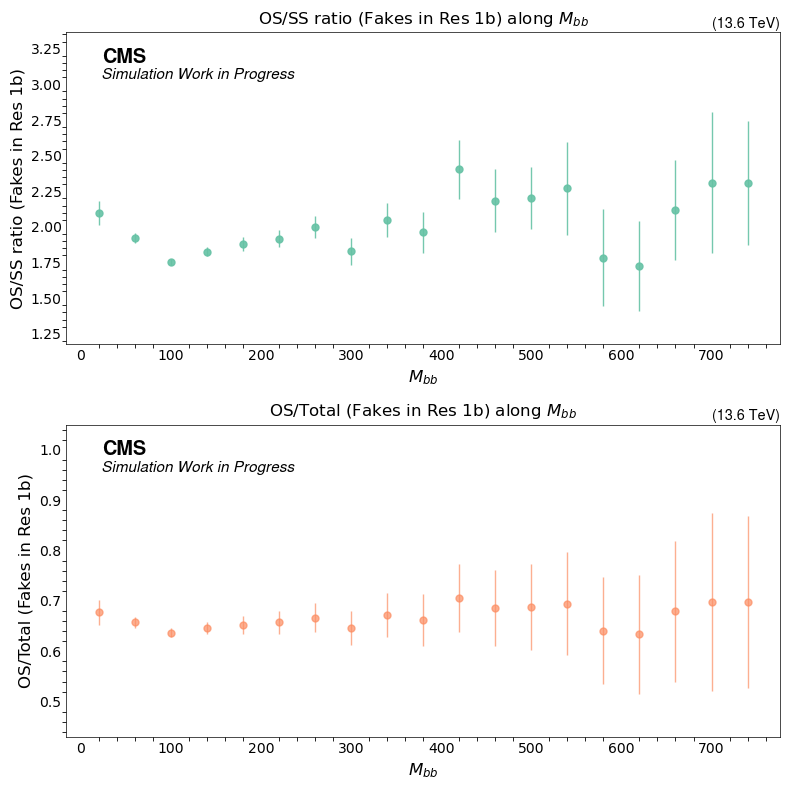

In [80]:
PlotUtil.corr_discrete(df_1b, 'OS', 'DiJet_mass', r'$M_{bb}$', 'OS/SS ratio (Fakes in Res 1b)', 'OS/Total (Fakes in Res 1b)', f'{plot_dir}/OSRatio_DiJetM_1b.png', 20, (0, 800), 'weight')

In [85]:
# further split the data into training and testing based on mass
def split_mass(df_ori):
    df = df_ori.copy()[(df_ori['DiJet_mass'] > 90)]
    condition = df['DiJet_mass'] > 160
    train = df[condition]
    test = df[~condition]
    return train, test

train_df, val_df = split_mass(df_2b)

In [86]:
cond = train_df['OS'] == False
ss_df = train_df[cond]
os_df = train_df[~cond]

In [87]:
val_cond = val_df['OS'] == False
val_ss_df = val_df[val_cond]
val_os_df = val_df[~val_cond]
# sig_cond = val_os_df['DiTau_mass'] > 60
# val_os_df = val_os_df[sig_cond]
# val_os_df = signal_id_level(val_os_df)

In [88]:
from src.utils.mathutil import ABCDUtil
ABCD_Helper = ABCDUtil(val_os_df, os_df, val_ss_df, ss_df, 'weight')
ABCD_Helper.get_all_stats()

          Events (Raw)  Events (Weighted)
Region                                   
Region A         77632               6284
Region B         84096               6565
Region C         37750               3364
Region D         37185               3236
The closure stats for Events (Raw): 
                                  Value
Metric                                 
Predicted events in A    85373 ± 689.75
Prediction/Actual ratio           1.100
Pull significance               -19.173
Deviation                       -11.223
Percentage difference             10.0%
The closure stats for Events (Weighted): 
                                 Value
Metric                                
Predicted events in A    6824 ± 187.95
Prediction/Actual ratio          1.086
Pull significance               -4.714
Deviation                       -2.872
Percentage difference             8.6%


In [26]:
results_dir = "/Users/yuntongzhou/Desktop/Dihiggszztt/output"
drop_kwds = ['Gen', 'weight_values', 'Weight_values', 'OS', 'group', 'gen', 'dataset', 'label', 'btag', 'RecoH_dR', 'id', 'year', 'Tau_charge']
rwgter = SingleXGBReweighter(ss_df, os_df, 'weight', results_dir)
rwgter.prep_data(drop_kwds)

Dropped  305  events with negative weights out of  39989  events.
Dropped  749  events with negative weights out of  95171  events.
X columns: 
Index(['LDTau_pt', 'LDTau_eta', 'LDTau_phi', 'LDTau_mass', 'LDTau_dxy',
       'LDTau_dz', 'SDTau_pt', 'SDTau_eta', 'SDTau_phi', 'SDTau_mass',
       'SDTau_dxy', 'SDTau_dz', 'LDBjet_pt', 'LDBjet_eta', 'LDBjet_phi',
       'LDBjet_mass', 'SDBjet_pt', 'SDBjet_eta', 'SDBjet_phi', 'SDBjet_mass',
       'DiTau_pt', 'DiTau_eta', 'DiTau_phi', 'DiTau_mass', 'DiJet_pt',
       'DiJet_eta', 'DiJet_phi', 'DiJet_mass', 'Tau_dR', 'Bjet_dR', 'HT',
       'LDTau_px', 'LDTau_py', 'LDTau_pz', 'SDTau_px', 'SDTau_py', 'SDTau_pz',
       'LDBjet_px', 'LDBjet_py', 'LDBjet_pz', 'SDBjet_px', 'SDBjet_py',
       'SDBjet_pz', 'DiTau_px', 'DiTau_py', 'DiTau_pz', 'DiJet_px', 'DiJet_py',
       'DiJet_pz'],
      dtype='object')


[0]	train-logloss:0.67217+0.00049	train-auc:0.65047+0.00174	train-rmse:0.48951+0.00025	test-logloss:0.67428+0.00257	test-auc:0.54968+0.00358	test-rmse:0.49055+0.00130
[20]	train-logloss:0.62389+0.00053	train-auc:0.82391+0.00220	train-rmse:0.46525+0.00026	test-logloss:0.66723+0.00273	test-auc:0.57476+0.00980	test-rmse:0.48711+0.00137
[40]	train-logloss:0.58484+0.00071	train-auc:0.87864+0.00206	train-rmse:0.44499+0.00035	test-logloss:0.66636+0.00306	test-auc:0.57550+0.00922	test-rmse:0.48671+0.00151
[49]	train-logloss:0.56917+0.00097	train-auc:0.89886+0.00150	train-rmse:0.43666+0.00049	test-logloss:0.66662+0.00305	test-auc:0.57520+0.00876	test-rmse:0.48684+0.00150
Optimal number of boosting rounds: 36


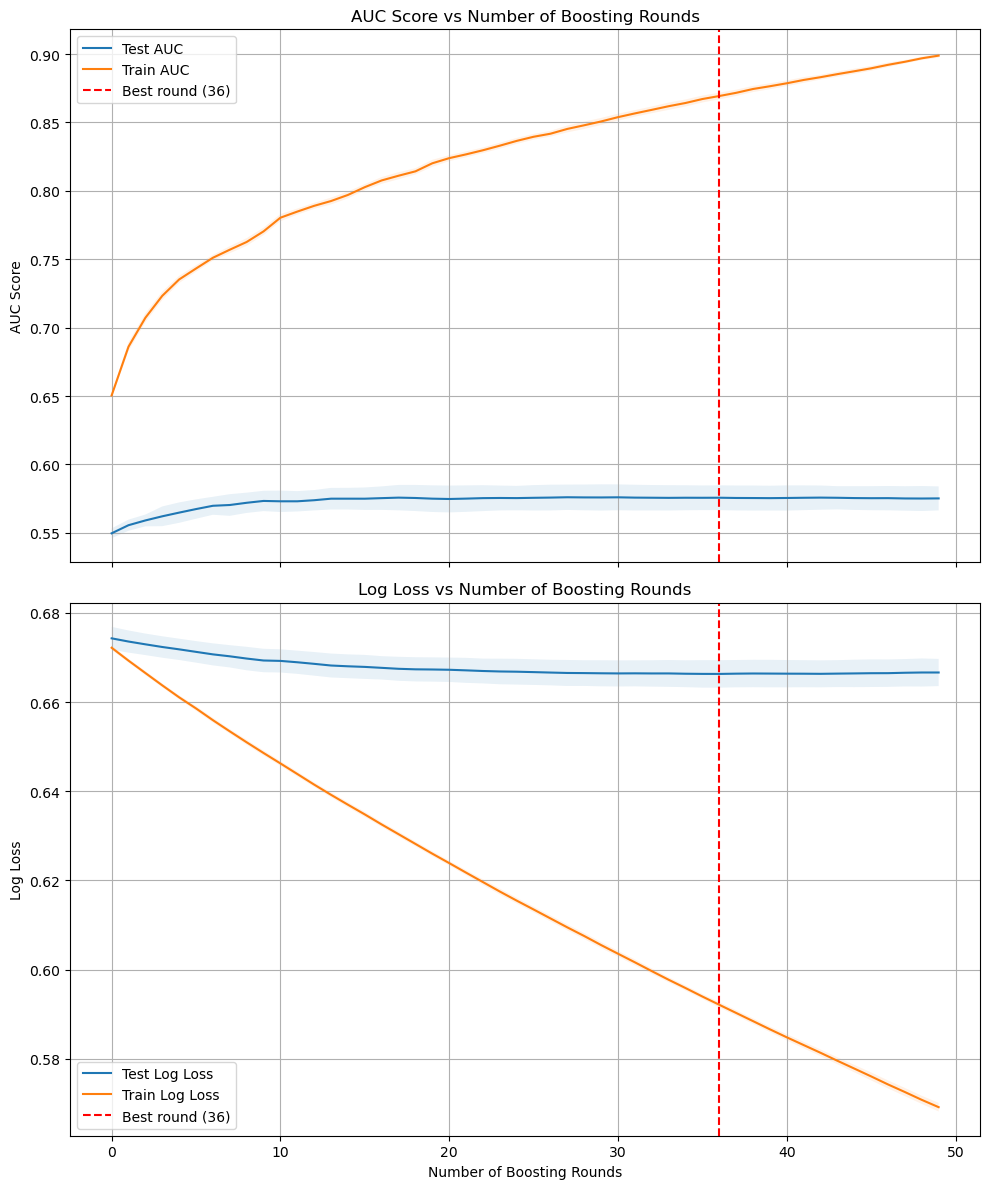

In [44]:
rwgter.boostingSearch(20, 50, booster='dart')

In [45]:
rwgter.train(save=True, savename='trained_models/depth_20_dart_fake.json')

[0]	train-logloss:0.67227	test-logloss:0.67167
[35]	train-logloss:0.59435	test-logloss:0.66073


ROC AUC Score: 0.591
Accuracy:  0.6170458927882762


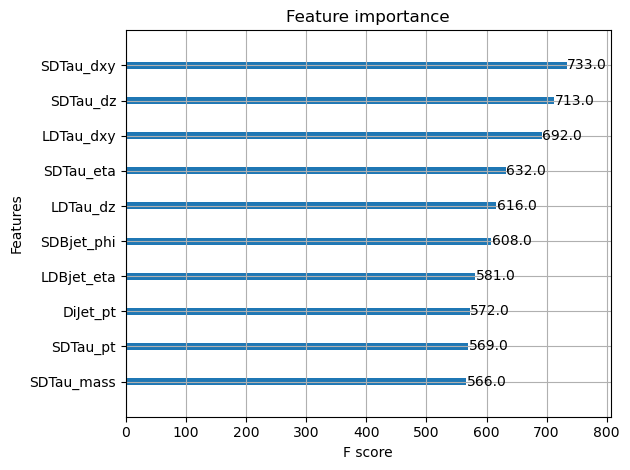

In [46]:
rwgter.evaluate()

In [47]:
# Change Naming Here
prefix = 'rwgt'
pjoin = os.path.join
savedir = pjoin('training', 'TTbar_only_fake_1b')

In [48]:
norm_SS = ss_df['weight'].sum()
norm_OS = os_df['weight'].sum()
rwgt_SS = rwgter.reweight(ss_df, norm_OS, drop_kwds, False)

Dropped  190  events with negative weights out of  30594  events.


In [49]:
norm_SS_val = val_ss_df['weight'].sum()
norm_OS_val = val_os_df['weight'].sum()
rwgt_SS_val = rwgter.reweight(val_ss_df, norm_OS_val, drop_kwds, False)

Dropped  183  events with negative weights out of  43017  events.


In [50]:
from src.plotting.visutil import CSVPlotter

In [51]:
plot_dir_name = 'TTbar_1b'
out_dir = f'/Users/yuntongzhou/Desktop/Dihiggszztt/output/plots/{plot_dir_name}'
data_dir = f'/Users/yuntongzhou/Desktop/Dihiggszztt/output/{savedir}'

modified_H_mass = {
    "DiTau_mass": {
        "hist": {'bins': 30, 'range': [0,400]},
        "plot": {'xlabel': r'Visible Mass (2$\tau$) (GeV)'}},
    "DiJet_mass": {
        "hist": {'bins': 40, 'range': [160,600]},
        "plot": {'xlabel': r'Invariant Mass (2b) (GeV)'}},
}
from config.plotsetting import tau_pt, dR

/Users/yuntongzhou/Desktop/Dihiggszztt/HHtobbtautau/src/utils/plotutil.py:94: RuntimeWarning: invalid value encountered in divide
  ratio = np.nan_to_num(num / den, nan=0., posinf=0.)
/Users/yuntongzhou/Desktop/Dihiggszztt/HHtobbtautau/src/utils/plotutil.py:96: RuntimeWarning: invalid value encountered in divide
  ratio * np.sqrt((num_err/num)**2 + (den_err/den)**2),
/Users/yuntongzhou/Desktop/Dihiggszztt/HHtobbtautau/src/utils/plotutil.py:94: RuntimeWarning: invalid value encountered in divide
  ratio = np.nan_to_num(num / den, nan=0., posinf=0.)
/Users/yuntongzhou/Desktop/Dihiggszztt/HHtobbtautau/src/utils/plotutil.py:96: RuntimeWarning: invalid value encountered in divide
  ratio * np.sqrt((num_err/num)**2 + (den_err/den)**2),
/Users/yuntongzhou/Desktop/Dihiggszztt/HHtobbtautau/src/utils/plotutil.py:94: RuntimeWarning: invalid value encountered in divide
  ratio = np.nan_to_num(num / den, nan=0., posinf=0.)
/Users/yuntongzhou/Desktop/Dihiggszztt/HHtobbtautau/src/utils/plotutil.py:96

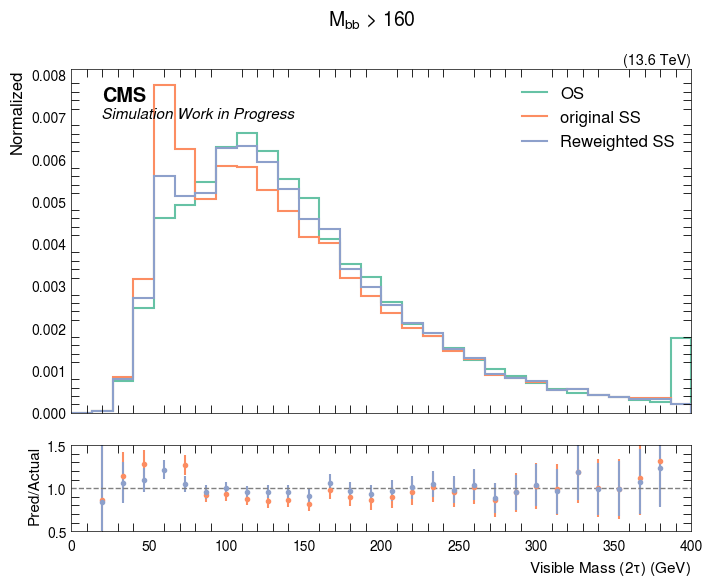

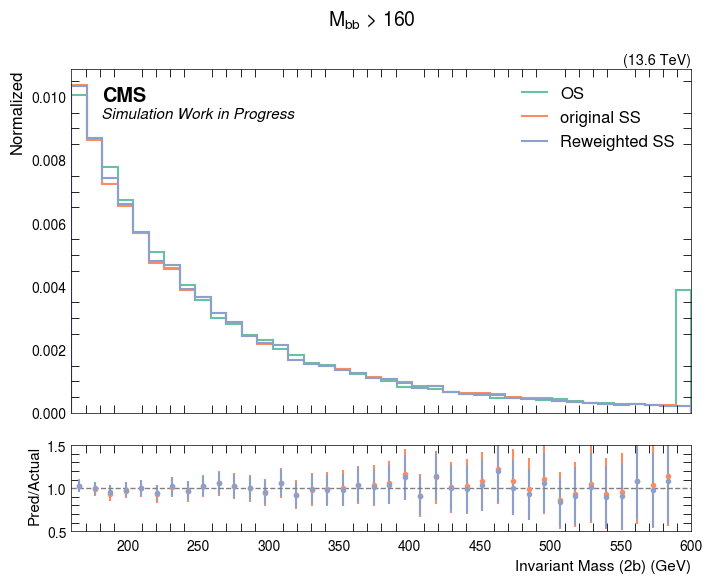

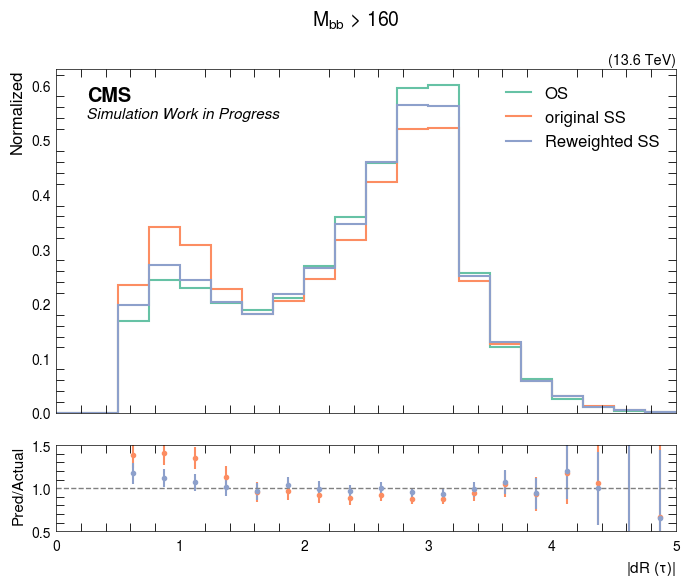

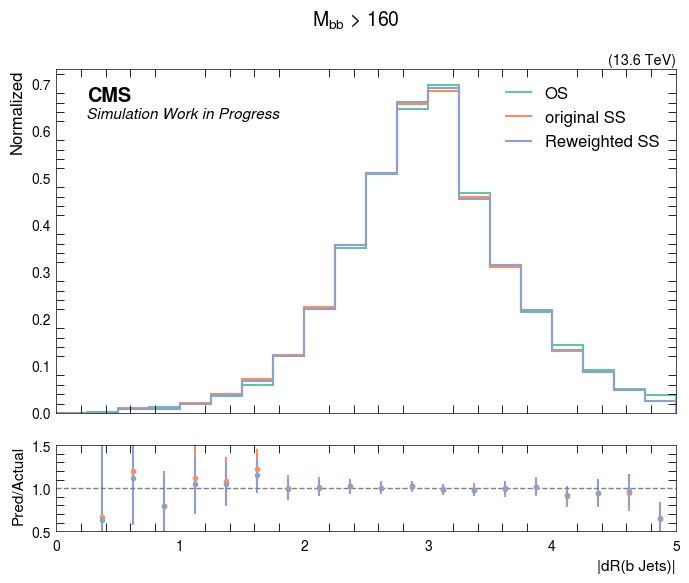

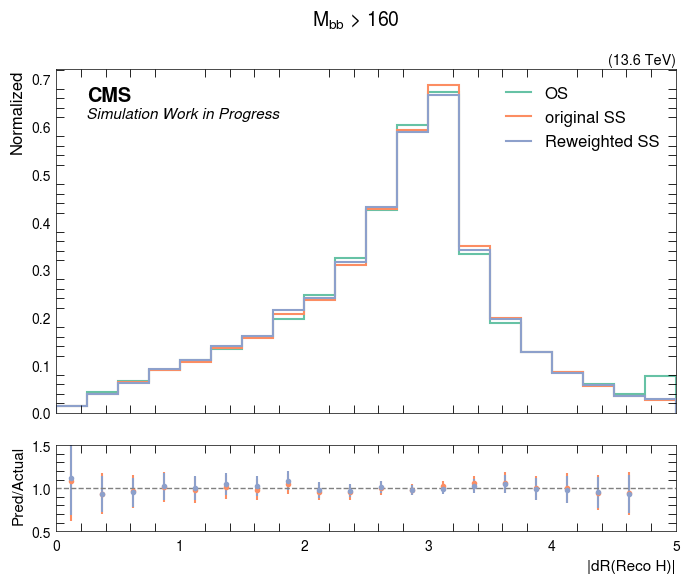

In [53]:
CSVPlotter.plot_shape([os_df, ss_df, rwgt_SS], ['OS', 'original SS', 'Reweighted SS'], modified_H_mass, 'Pred/Actual', out_dir, title=r'$M_{bb}$ > 160', save_suffix='rwgt')
CSVPlotter.plot_shape([os_df, ss_df, rwgt_SS], ['OS', 'original SS', 'Reweighted SS'], dR, 'Pred/Actual', out_dir, title=r'$M_{bb}$ > 160', save_suffix='rwgt')

/Users/yuntongzhou/Desktop/Dihiggszztt/HHtobbtautau/src/utils/plotutil.py:94: RuntimeWarning: invalid value encountered in divide
  ratio = np.nan_to_num(num / den, nan=0., posinf=0.)
/Users/yuntongzhou/Desktop/Dihiggszztt/HHtobbtautau/src/utils/plotutil.py:96: RuntimeWarning: invalid value encountered in divide
  ratio * np.sqrt((num_err/num)**2 + (den_err/den)**2),
/Users/yuntongzhou/Desktop/Dihiggszztt/HHtobbtautau/src/utils/plotutil.py:94: RuntimeWarning: invalid value encountered in divide
  ratio = np.nan_to_num(num / den, nan=0., posinf=0.)
/Users/yuntongzhou/Desktop/Dihiggszztt/HHtobbtautau/src/utils/plotutil.py:96: RuntimeWarning: invalid value encountered in divide
  ratio * np.sqrt((num_err/num)**2 + (den_err/den)**2),
/Users/yuntongzhou/Desktop/Dihiggszztt/HHtobbtautau/src/utils/plotutil.py:94: RuntimeWarning: invalid value encountered in divide
  ratio = np.nan_to_num(num / den, nan=0., posinf=0.)
/Users/yuntongzhou/Desktop/Dihiggszztt/HHtobbtautau/src/utils/plotutil.py:96

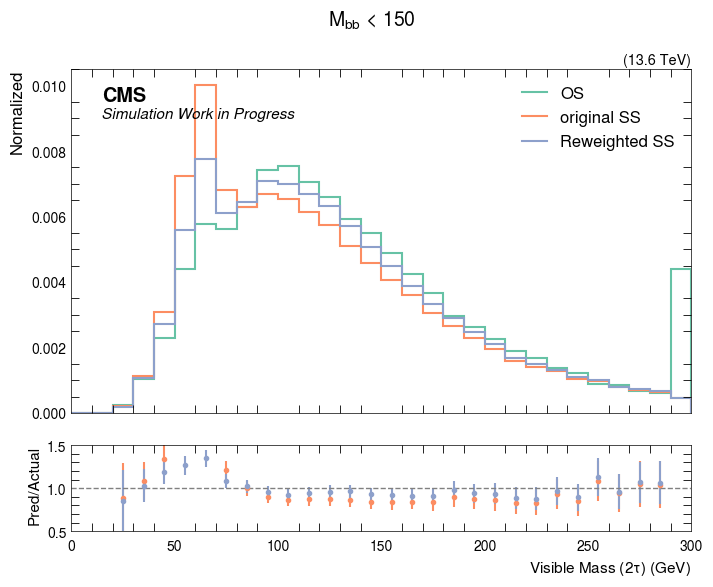

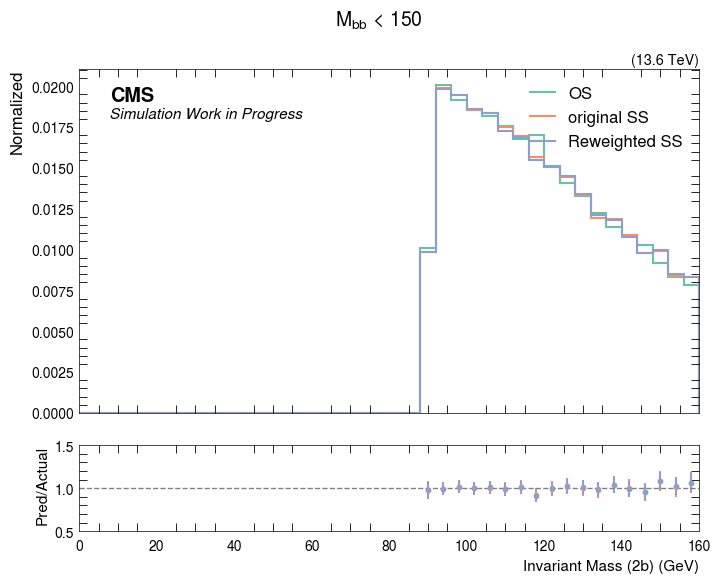

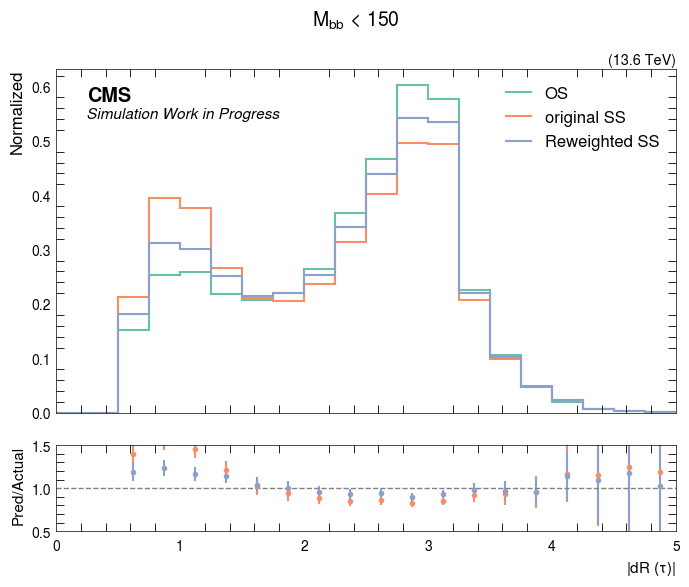

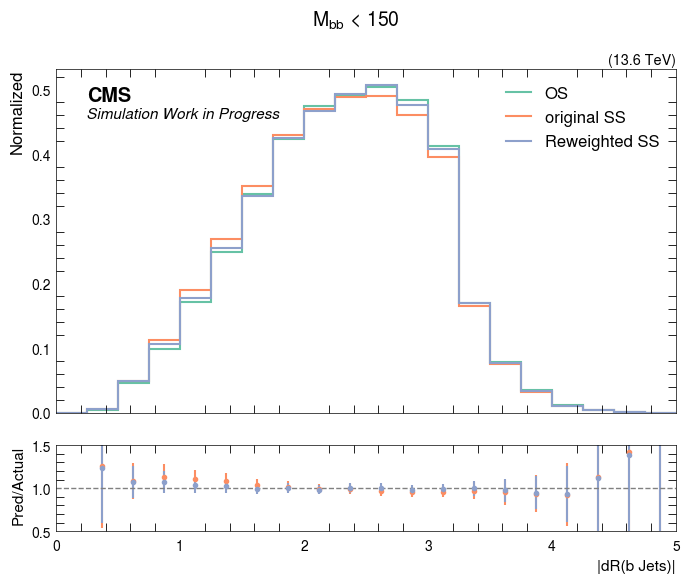

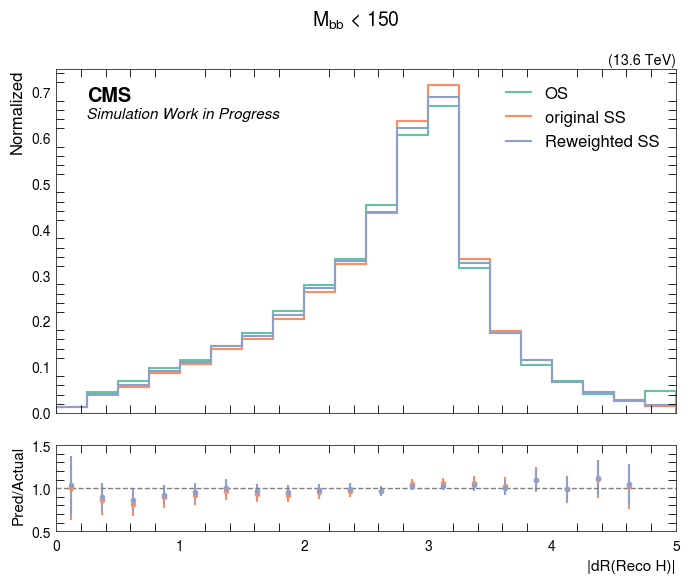

In [54]:
modified_H_mass = {
    "DiTau_mass": {
        "hist": {'bins': 30, 'range': [0,300]},
        "plot": {'xlabel': r'Visible Mass (2$\tau$) (GeV)'}},
    "DiJet_mass": {
        "hist": {'bins': 40, 'range': [0,160]},
        "plot": {'xlabel': r'Invariant Mass (2b) (GeV)'}},
}
CSVPlotter.plot_shape([val_os_df, val_ss_df, rwgt_SS_val], ['OS', 'original SS', 'Reweighted SS'], modified_H_mass, 'Pred/Actual', out_dir, title=r'$M_{bb}$ < 150', save_suffix='rwgt_sig')
CSVPlotter.plot_shape([val_os_df, val_ss_df, rwgt_SS_val], ['OS', 'original SS', 'Reweighted SS'], dR, 'Pred/Actual', out_dir, title=r'$M_{bb}$ < 150', save_suffix='rwgt_sig')